# AI-Guided Optimization of Quantum Fourier Transform Circuits Under Noise Using Bayesian Optimization

This notebook implements a reproducible, modular research pipeline to test whether Bayesian Optimization (BO) discovers superior QFT circuit configurations under realistic NISQ-style noise compared with Random Search and a human heuristic baseline.

The notebook is organized as a full scientific workflow:
1. Controlled experimental setup
2. Multi-method optimization with matched budgets
3. Statistical testing
4. Scaling and ablation studies
5. Interpretability and optional hardware validation
6. Automatic result persistence


In [ ]:
# Install dependencies (Colab/local notebook)
%pip install -q qiskit qiskit-aer qiskit-ibm-runtime numpy matplotlib pandas scikit-learn scipy



## SECTION 1 — Imports and Global Configuration


In [ ]:
import os
import json
import copy
import random
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, norm

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit_ibm_runtime import QiskitRuntimeService

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel

warnings.filterwarnings('ignore')

CONFIG = {
    "SHOTS": 2048,
    "BUDGET": 60,
    "SEEDS": list(range(10)),
    "ALPHA": 0.0015,
    "BETA": 0.0005,
    "T_COUNTS": [4, 5, 6],
    "NOISE_MULTIPLIER": 1.0,
    "USE_REAL_BACKEND": False,
    "USE_IBM_NOISE_MODEL": True,
    "IBM_BACKEND_NAME": "ibm_brisbane",
    "SEARCH_SHOTS": 512,
    "RERANK_SHOTS": 4096,
    "BO_REPEATS": 2,
    "RERANK_REPEATS": 3,
    "RERANK_TOP_K": 8,
    "USE_ADAPTIVE_SHOTS": True,
}

MAIN_T_COUNT = 5
PHASE_FRACTION = 1.0 / 8.0

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'lines.linewidth': 2.2,
})


def set_global_seed(seed: int = 0):
    random.seed(seed)
    np.random.seed(seed)


set_global_seed(0)
print('CONFIG loaded and global seed set.')






CONFIG loaded and global seed set.


## SECTION 2 — Backend and Noise Model Setup


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=os.environ["IBM_QUANTUM_TOKEN"],  # set via environment variable
    overwrite=True
)






In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.noise import NoiseModel
from qiskit_aer import AerSimulator

service = QiskitRuntimeService(instance="operator_7")

# Pick an accessible backend
hw_backends = service.backends(simulator=False, operational=True)
print([b.name for b in hw_backends])

backend = hw_backends[0]  # or choose one explicitly
CONFIG["USE_IBM_NOISE_MODEL"] = True
CONFIG["IBM_BACKEND_NAME"] = backend.name

noise_model = NoiseModel.from_backend(backend)
BACKEND_CTX = {
    "simulator": AerSimulator(
        noise_model=noise_model,
        basis_gates=noise_model.basis_gates,
        coupling_map=backend.coupling_map,
    ),
    "noise_model": noise_model,
    "noise_source": "ibm_backend",
    "ibm_backend_name": backend.name,
    "transpile_backend": backend,
}

print("Loaded IBM noise model from:", backend.name)


['ibm_fez', 'ibm_boston', 'ibm_pittsburgh', 'ibm_kingston', 'ibm_marrakesh', 'ibm_torino']
Loaded IBM noise model from: ibm_fez


In [ ]:
def _setup_manual_noise_backend(config=CONFIG):
    """Manual NISQ-style noise model (second option / fallback)."""
    multiplier = float(config["NOISE_MULTIPLIER"])

    p1 = min(0.0015 * multiplier, 0.15)
    p2 = min(0.0150 * multiplier, 0.35)
    p_meas = min(0.0200 * multiplier, 0.20)

    noise_model = NoiseModel()

    one_qubit_gates = ["id", "x", "sx", "rz", "h"]
    two_qubit_gates = ["cx", "cp", "swap"]

    one_q_err = depolarizing_error(p1, 1)
    two_q_err = depolarizing_error(p2, 2)

    for g in one_qubit_gates:
        noise_model.add_all_qubit_quantum_error(one_q_err, g)
    for g in two_qubit_gates:
        noise_model.add_all_qubit_quantum_error(two_q_err, g)

    readout = ReadoutError([[1 - p_meas, p_meas], [p_meas, 1 - p_meas]])
    noise_model.add_all_qubit_readout_error(readout)

    simulator = AerSimulator(noise_model=noise_model)
    return {
        "simulator": simulator,
        "noise_model": noise_model,
        "noise_source": "manual_fallback",
        "p1": p1,
        "p2": p2,
        "p_meas": p_meas,
        "ibm_backend_name": None,
        "transpile_backend": None,
    }


def setup_backend_and_noise(config=CONFIG):
    """
    Default: IBM backend-derived noise model for AerSimulator.
    Second option: manual synthetic noise model (set USE_IBM_NOISE_MODEL=False).
    """
    use_ibm_noise = bool(config.get("USE_IBM_NOISE_MODEL", True))

    if use_ibm_noise:
        try:
            service = QiskitRuntimeService(
                channel="ibm_quantum_platform",
                instance="operator_7",
            )

            backend_name = config.get("IBM_BACKEND_NAME", None)
            backend = service.backend(backend_name) if backend_name else service.least_busy(
                simulator=False,
                operational=True,
            )

            noise_model = NoiseModel.from_backend(backend)
            simulator = AerSimulator(
                noise_model=noise_model,
                basis_gates=noise_model.basis_gates,
                coupling_map=backend.coupling_map,
            )

            return {
                "simulator": simulator,
                "noise_model": noise_model,
                "noise_source": "ibm_backend",
                "p1": None,
                "p2": None,
                "p_meas": None,
                "ibm_backend_name": backend.name,
                "transpile_backend": backend,
            }
        except Exception as exc:
            print(f"IBM noise model unavailable, falling back to manual noise model: {exc}")
            return _setup_manual_noise_backend(config)

    return _setup_manual_noise_backend(config)


BACKEND_CTX = setup_backend_and_noise(CONFIG)
print("Noisy backend ready:", {k: BACKEND_CTX[k] for k in ["p1", "p2", "p_meas"]})
print("noise_source:", BACKEND_CTX["noise_source"])
print("ibm_backend_name:", BACKEND_CTX["ibm_backend_name"])
print("has transpile backend:", BACKEND_CTX["transpile_backend"] is not None)


Noisy backend ready: {'p1': None, 'p2': None, 'p_meas': None}
noise_source: ibm_backend
ibm_backend_name: ibm_fez
has transpile backend: True


## SECTION 3 — Circuit Construction


In [ ]:
def inverse_qft(circuit, qubits, qft_type='exact', k=None):
    # Apply inverse QFT in-place with optional AQFT truncation k.
    n = len(qubits)

    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - 1 - i])

    for j in range(n):
        for m in range(j):
            dist = j - m
            if qft_type == 'aqft' and k is not None and dist > int(k):
                continue
            circuit.cp(-np.pi / (2 ** dist), qubits[j], qubits[m])
        circuit.h(qubits[j])


def build_circuit(qft_type, k, opt_level, t_count, r, layout_strategy="sabre", routing_method="sabre", backend_ctx=None):
    backend_ctx = BACKEND_CTX if backend_ctx is None else backend_ctx

    count = QuantumRegister(t_count, "count")
    anc = QuantumRegister(1, "anc")
    c_out = ClassicalRegister(t_count, "c")
    qc = QuantumCircuit(count, anc, c_out)

    qc.x(anc[0])
    for q in count:
        qc.h(q)

    reps = max(1, int(r))
    for j, q in enumerate(count):
        angle = 2 * np.pi * PHASE_FRACTION * (2 ** j) / reps
        for _ in range(reps):
            qc.cp(angle, q, anc[0])

    inverse_qft(qc, list(count), qft_type=qft_type, k=k)
    qc.measure(count, c_out)

    coupling_map = None
    basis_gates = None

    if backend_ctx.get("noise_source") == "ibm_backend":
        backend = backend_ctx.get("transpile_backend")
        if backend is not None:
            coupling_map = backend.coupling_map
        basis_gates = backend_ctx["noise_model"].basis_gates

    tqc = transpile(
        qc,
        basis_gates=basis_gates,
        coupling_map=coupling_map,
        optimization_level=int(opt_level),
        seed_transpiler=0,
        layout_method="sabre",
        routing_method="sabre",
    )
    return tqc




## SECTION 4 — Objective Function


In [ ]:
def objective(success_probability, depth, cnot_count, config=CONFIG, use_hardware_penalty=True):
    beta = float(config['BETA']) if use_hardware_penalty else 0.0
    return float(success_probability) - float(config['ALPHA']) * float(depth) - beta * float(cnot_count)


def evaluate_configuration(params, backend_ctx=None, config=CONFIG, use_hardware_penalty=True, seed=0, shots_override=None):
    backend_ctx = BACKEND_CTX if backend_ctx is None else backend_ctx
    shots = int(config['SHOTS'] if shots_override is None else shots_override)

    circuit = build_circuit(
        qft_type=params['qft_type'],
        k=params.get('k'),
        opt_level=params['opt_level'],
        t_count=params['t_count'],
        r=params['r'],
        layout_strategy=params.get('layout_strategy', 'sabre'),
        routing_method=params.get('routing_method', 'sabre'),
        backend_ctx=backend_ctx,
    )

    job = backend_ctx['simulator'].run(circuit, shots=shots, seed_simulator=int(seed))
    result = job.result()
    counts = result.get_counts()

    success_probability = (max(counts.values()) / shots) if counts else 0.0
    depth = int(circuit.depth())
    cnot_count = int(circuit.count_ops().get('cx', 0))

    score = objective(success_probability, depth, cnot_count, config=config, use_hardware_penalty=use_hardware_penalty)

    return {
        'params': copy.deepcopy(params),
        'success': float(success_probability),
        'depth': depth,
        'cnot': cnot_count,
        'score': float(score),
        'shots': shots,
    }



## SECTION 5 — Search Algorithms


In [ ]:
def make_search_space(t_count, allow_aqft=True, fixed_opt_level=None, remove_k=False):
    """
    Focused search space to improve BO sample efficiency on mixed discrete parameters.
    """
    qft_types = ['aqft'] if allow_aqft else ['exact']
    opt_levels = [int(fixed_opt_level)] if fixed_opt_level is not None else [2, 3]
    r_values = [1, 2, 3]
    layout_strategies = ['sabre']
    routing_methods = [ 'sabre']

    if remove_k:
        k_candidates = [None]
    else:
        base = sorted({max(1, t_count // 3), max(1, t_count // 2), max(1, t_count - 1)})
        k_candidates = base

    space = []
    for qft_type in qft_types:
        k_values = [None] if qft_type == 'exact' else k_candidates
        for k in k_values:
            for opt_level in opt_levels:
                for r in r_values:
                    for layout_strategy in layout_strategies:
                        for routing_method in routing_methods:
                            space.append({
                                'qft_type': qft_type,
                                'k': k,
                                'opt_level': int(opt_level),
                                't_count': int(t_count),
                                'r': int(r),
                                'layout_strategy': layout_strategy,
                                'routing_method': routing_method,
                            })
    return space


def encode_config(cfg):
    layout_map = {'trivial': 0.0, 'dense': 1.0, 'sabre': 2.0}
    routing_map = {'basic': 0.0, 'lookahead': 1.0, 'sabre': 2.0}
    return np.array([
        0.0 if cfg['qft_type'] == 'exact' else 1.0,
        -1.0 if cfg.get('k') is None else float(cfg['k']),
        float(cfg['opt_level']),
        float(cfg['t_count']),
        float(cfg['r']),
        layout_map.get(cfg.get('layout_strategy', 'sabre'), 2.0),
        routing_map.get(cfg.get('routing_method', 'sabre'), 2.0),
    ], dtype=float)


def expected_improvement(mu, sigma, y_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-12)
    improvement = mu - y_best - xi
    z = improvement / sigma
    return improvement * norm.cdf(z) + sigma * norm.pdf(z)


def _record_trial(history, trial, method, seed, iteration):
    row = copy.deepcopy(trial)
    row['method'] = method
    row['seed'] = int(seed)
    row['iteration'] = int(iteration)
    history.append(row)


def _evaluate_repeated(cfg, backend_ctx, config, use_hardware_penalty, base_seed, shots, repeats):
    vals = []
    for r in range(int(repeats)):
        vals.append(
            evaluate_configuration(
                cfg,
                backend_ctx=backend_ctx,
                config=config,
                use_hardware_penalty=use_hardware_penalty,
                seed=int(base_seed) + r,
                shots_override=int(shots),
            )
        )

    out = copy.deepcopy(vals[-1])
    out['success'] = float(np.mean([v['success'] for v in vals]))
    out['depth'] = int(round(np.mean([v['depth'] for v in vals])))
    out['cnot'] = int(round(np.mean([v['cnot'] for v in vals])))
    out['score'] = float(np.mean([v['score'] for v in vals]))
    out['shots'] = int(shots)
    out['repeats'] = int(repeats)
    return out


def random_search(space, backend_ctx, budget, seed=0, config=CONFIG, use_hardware_penalty=True):
    rng = np.random.default_rng(seed)
    history = []
    curve = []
    best = -1e9
    search_shots = int(config.get('SEARCH_SHOTS', config['SHOTS']))

    for i in range(int(budget)):
        cfg = copy.deepcopy(space[int(rng.integers(len(space)))])
        trial = evaluate_configuration(
            cfg,
            backend_ctx=backend_ctx,
            config=config,
            use_hardware_penalty=use_hardware_penalty,
            seed=seed * 1000 + i,
            shots_override=search_shots,
        )
        _record_trial(history, trial, 'random', seed, i)
        best = max(best, trial['score'])
        curve.append(float(best))

    return curve, history


def human_heuristic_search(space, backend_ctx, budget, seed=0, config=CONFIG, use_hardware_penalty=True):
    """
    Fairer baseline: lightweight rules + stochastic tie-breaking, without deep pre-ranking.
    """
    rng = np.random.default_rng(seed)
    history = []
    curve = []
    best = -1e9
    search_shots = int(config.get('SEARCH_SHOTS', config['SHOTS']))

    template_pool = []
    for cfg in space:
        if cfg['opt_level'] in [2, 3] and cfg['r'] in [1, 2]:
            template_pool.append(cfg)

    if not template_pool:
        template_pool = space

    for i in range(int(budget)):
        if rng.random() < 0.55:
            cand = template_pool[int(rng.integers(len(template_pool)))]
        else:
            cand = space[int(rng.integers(len(space)))]

        cfg = copy.deepcopy(cand)
        trial = evaluate_configuration(
            cfg,
            backend_ctx=backend_ctx,
            config=config,
            use_hardware_penalty=use_hardware_penalty,
            seed=seed * 1000 + i,
            shots_override=search_shots,
        )
        _record_trial(history, trial, 'human', seed, i)
        best = max(best, trial['score'])
        curve.append(float(best))

    return curve, history


def bayesian_optimization(space, backend_ctx, budget, seed=0, config=CONFIG, use_hardware_penalty=True):
    rng = np.random.default_rng(seed)
    history = []
    curve = []
    best = -1e9

    X = []
    y = []

    encoded_space = np.array([encode_config(c) for c in space], dtype=float)
    seen = set()

    search_shots = int(config.get('SEARCH_SHOTS', config['SHOTS']))
    rerank_shots = int(config.get('RERANK_SHOTS', config['SHOTS']))
    bo_repeats = int(config.get('BO_REPEATS', 1))
    rerank_repeats = int(config.get('RERANK_REPEATS', 2))
    rerank_top_k = int(config.get('RERANK_TOP_K', 5))
    adaptive = bool(config.get('USE_ADAPTIVE_SHOTS', True))

    # Higher observation noise to stabilize GP under low-shot evaluations.
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(encoded_space.shape[1]), nu=2.5) + WhiteKernel(noise_level=1e-3)
    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=True,
        random_state=int(seed),
        n_restarts_optimizer=6,
    )

    init_points = min(max(15, int(0.40 * int(budget))), int(budget))

    def _anchor_indices():
        scored = []
        for idx, cfg in enumerate(space):
            aqft_bonus = 1 if cfg['qft_type'] == 'aqft' else 0
            k_val = cfg['k'] if cfg['k'] is not None else cfg['t_count']
            layout_bonus = 1 if cfg.get('layout_strategy', 'sabre') == 'sabre' else 0
            routing_bonus = 1 if cfg.get('routing_method', 'sabre') == 'sabre' else 0
            score = (
                aqft_bonus,
                cfg['opt_level'],
                layout_bonus,
                routing_bonus,
                -cfg['r'],
                -abs(k_val - max(1, cfg['t_count'] // 2)),
            )
            scored.append((score, idx))
        scored.sort(reverse=True)
        return [idx for _, idx in scored[: min(5, len(scored))]]

    anchors = _anchor_indices()

    for i in range(int(budget)):
        if i < init_points or len(X) < 4:
            if i < len(anchors) and anchors[i] not in seen:
                idx = anchors[i]
            else:
                pool = [j for j in range(len(space)) if j not in seen]
                if not pool:
                    pool = list(range(len(space)))
                idx = int(rng.choice(pool))
            cfg = copy.deepcopy(space[idx])
        else:
            X_train = np.array(X, dtype=float)
            y_train = np.array(y, dtype=float)
            gp.fit(X_train, y_train)

            candidate_idx = [j for j in range(len(space)) if j not in seen]
            if not candidate_idx:
                candidate_idx = list(range(len(space)))

            Xcand = encoded_space[candidate_idx]
            mu, sigma = gp.predict(Xcand, return_std=True)

            progress = float(i) / max(1.0, float(budget) - 1.0)
            xi = max(0.03, 0.25 * (1.0 - progress))
            ei = expected_improvement(mu, sigma, np.max(y_train), xi=xi)

            sigma_norm = sigma / (np.max(sigma) + 1e-12)
            acq = ei + 0.08 * sigma_norm

            topk = min(5, len(acq))
            top_local = np.argpartition(acq, -topk)[-topk:]
            chosen_local = int(rng.choice(top_local))
            idx = int(candidate_idx[chosen_local])
            cfg = copy.deepcopy(space[idx])

        progress = float(i) / max(1.0, float(budget) - 1.0)
        if adaptive:
            iter_shots = search_shots if progress < 0.70 else max(search_shots, int(0.5 * rerank_shots))
            iter_repeats = 1 if progress < 0.70 else bo_repeats
        else:
            iter_shots = search_shots
            iter_repeats = bo_repeats

        trial = _evaluate_repeated(
            cfg,
            backend_ctx=backend_ctx,
            config=config,
            use_hardware_penalty=use_hardware_penalty,
            base_seed=seed * 100000 + i * 20,
            shots=iter_shots,
            repeats=iter_repeats,
        )
        _record_trial(history, trial, 'bo', seed, i)

        seen.add(idx)
        X.append(encoded_space[idx])
        y.append(trial['score'])

        best = max(best, trial['score'])
        curve.append(float(best))

    # High-shot re-ranking of top BO candidates improves final selection reliability.
    unique = {}
    for r in history:
        key = tuple(sorted(r['params'].items()))
        if key not in unique or r['score'] > unique[key]['score']:
            unique[key] = r

    top = sorted(unique.values(), key=lambda x: x['score'], reverse=True)[: max(1, rerank_top_k)]

    for j, row in enumerate(top):
        cfg = copy.deepcopy(row['params'])
        trial = _evaluate_repeated(
            cfg,
            backend_ctx=backend_ctx,
            config=config,
            use_hardware_penalty=use_hardware_penalty,
            base_seed=seed * 200000 + j * 50,
            shots=rerank_shots,
            repeats=rerank_repeats,
        )
        trial['phase'] = 'rerank'
        _record_trial(history, trial, 'bo', seed, int(budget) + j)
        best = max(best, trial['score'])
        curve.append(float(best))

    return curve, history



## SECTION 6 — Experiment Runner


In [ ]:
def run_suite(config=CONFIG, t_count=MAIN_T_COUNT, allow_aqft=True, fixed_opt_level=None, remove_k=False, use_hardware_penalty=True, backend_ctx=None):
    backend_ctx = BACKEND_CTX if backend_ctx is None else backend_ctx
    space = make_search_space(
        t_count=t_count,
        allow_aqft=allow_aqft,
        fixed_opt_level=fixed_opt_level,
        remove_k=remove_k,
    )

    results = {'random': [], 'bo': [], 'human': []}
    curves = {'random': [], 'bo': [], 'human': []}

    for seed in config['SEEDS']:
        c_r, h_r = random_search(space, backend_ctx, config['BUDGET'], seed=seed, config=config, use_hardware_penalty=use_hardware_penalty)
        c_b, h_b = bayesian_optimization(space, backend_ctx, config['BUDGET'], seed=seed, config=config, use_hardware_penalty=use_hardware_penalty)
        c_h, h_h = human_heuristic_search(space, backend_ctx, config['BUDGET'], seed=seed, config=config, use_hardware_penalty=use_hardware_penalty)

        results['random'].append(h_r)
        results['bo'].append(h_b)
        results['human'].append(h_h)

        curves['random'].append(c_r)
        curves['bo'].append(c_b)
        curves['human'].append(c_h)

    return {
        'results': results,
        'curves': curves,
        'meta': {
            't_count': int(t_count),
            'budget': int(config['BUDGET']),
            'seeds': list(config['SEEDS']),
            'space_size': len(space),
            'allow_aqft': bool(allow_aqft),
            'fixed_opt_level': fixed_opt_level,
            'remove_k': bool(remove_k),
            'use_hardware_penalty': bool(use_hardware_penalty),
        },
    }




## SECTION 7 — Statistical Analysis


In [ ]:
def flatten_trials(bundle, method=None):
    rows = []
    methods = [method] if method else list(bundle['results'].keys())
    for m in methods:
        for seed_trials in bundle['results'][m]:
            rows.extend(seed_trials)
    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows)
    p = out['params'].apply(pd.Series)
    for col in p.columns:
        out[f'param_{col}'] = p[col]
    return out.drop(columns=['params'])


def final_scores_by_method(bundle):
    out = {}
    for method, curves in bundle['curves'].items():
        out[method] = [float(c[-1]) for c in curves if len(c) > 0]
    return out


def mean_std_ci(values):
    arr = np.array(values, dtype=float)
    n = len(arr)
    mean = float(np.mean(arr)) if n else np.nan
    std = float(np.std(arr, ddof=1)) if n > 1 else 0.0
    ci95 = float(1.96 * std / np.sqrt(n)) if n > 1 else 0.0
    return mean, std, ci95


def cohens_d(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    va = np.var(a, ddof=1)
    vb = np.var(b, ddof=1)
    pooled = np.sqrt(((len(a) - 1) * va + (len(b) - 1) * vb) / (len(a) + len(b) - 2))
    if pooled <= 1e-12:
        return 0.0
    return float((np.mean(a) - np.mean(b)) / pooled)


def statistical_analysis(bundle):
    finals = final_scores_by_method(bundle)

    summary = {}
    for method, vals in finals.items():
        mean, std, ci = mean_std_ci(vals)
        summary[method] = {'mean': mean, 'std': std, 'ci95': ci, 'n': len(vals)}

    bo = finals.get('bo', [])
    rnd = finals.get('random', [])
    human = finals.get('human', [])

    if len(bo) > 1 and len(rnd) > 1:
        t_stat_br, p_val_br = ttest_ind(bo, rnd, equal_var=False)
    else:
        t_stat_br, p_val_br = np.nan, np.nan

    if len(bo) > 1 and len(human) > 1:
        t_stat_bh, p_val_bh = ttest_ind(bo, human, equal_var=False)
    else:
        t_stat_bh, p_val_bh = np.nan, np.nan

    effect_br = cohens_d(bo, rnd)
    effect_bh = cohens_d(bo, human)

    win_rate_vs_random = float(np.mean([a > b for a, b in zip(bo, rnd)])) if len(bo) == len(rnd) and len(bo) > 0 else np.nan
    win_rate_vs_human = float(np.mean([a > b for a, b in zip(bo, human)])) if len(bo) == len(human) and len(bo) > 0 else np.nan

    evidence_table = pd.DataFrame([
        {
            'comparison': 'BO vs Random',
            'mean_diff': float(np.mean(bo) - np.mean(rnd)) if bo and rnd else np.nan,
            'p_value': float(p_val_br) if not np.isnan(p_val_br) else np.nan,
            'effect_size_d': float(effect_br) if not np.isnan(effect_br) else np.nan,
            'bo_win_rate': win_rate_vs_random,
        },
        {
            'comparison': 'BO vs Human',
            'mean_diff': float(np.mean(bo) - np.mean(human)) if bo and human else np.nan,
            'p_value': float(p_val_bh) if not np.isnan(p_val_bh) else np.nan,
            'effect_size_d': float(effect_bh) if not np.isnan(effect_bh) else np.nan,
            'bo_win_rate': win_rate_vs_human,
        },
    ])

    print('Final-score summary (mean +/- 95% CI):')
    for method in ['bo', 'random', 'human']:
        if method in summary:
            s = summary[method]
            print(f"  {method:>6}: {s['mean']:.4f} +/- {s['ci95']:.4f} (std={s['std']:.4f}, n={s['n']})")

    print(f"\nBO vs Random: p-value={p_val_br:.6f}, Cohen's d={effect_br:.4f}, BO win rate={win_rate_vs_random:.2%}")
    print(f"BO vs Human:  p-value={p_val_bh:.6f}, Cohen's d={effect_bh:.4f}, BO win rate={win_rate_vs_human:.2%}")
    print('\nEvidence table:')
    print(evidence_table.to_string(index=False))

    return {
        'summary': summary,
        'bo_vs_random': {
            't_stat': float(t_stat_br) if not np.isnan(t_stat_br) else None,
            'p_value': float(p_val_br) if not np.isnan(p_val_br) else None,
            'effect_size_d': float(effect_br) if not np.isnan(effect_br) else None,
            'bo_win_rate': float(win_rate_vs_random) if not np.isnan(win_rate_vs_random) else None,
        },
        'bo_vs_human': {
            't_stat': float(t_stat_bh) if not np.isnan(t_stat_bh) else None,
            'p_value': float(p_val_bh) if not np.isnan(p_val_bh) else None,
            'effect_size_d': float(effect_bh) if not np.isnan(effect_bh) else None,
            'bo_win_rate': float(win_rate_vs_human) if not np.isnan(win_rate_vs_human) else None,
        },
        'evidence_table': evidence_table,
        'final_scores': finals,
    }




## SECTION 8 — Scaling Experiment


In [ ]:
def run_scaling_experiment(config=CONFIG, backend_ctx=None):
    backend_ctx = BACKEND_CTX if backend_ctx is None else backend_ctx
    rows = []

    for t_count in config['T_COUNTS']:
        space = make_search_space(t_count=t_count, allow_aqft=True, fixed_opt_level=None, remove_k=False)

        for method in ['bo', 'random']:
            best_scores = []
            for seed in config['SEEDS']:
                if method == 'bo':
                    curve, _ = bayesian_optimization(space, backend_ctx, config['BUDGET'], seed=seed, config=config, use_hardware_penalty=True)
                else:
                    curve, _ = random_search(space, backend_ctx, config['BUDGET'], seed=seed, config=config, use_hardware_penalty=True)
                best_scores.append(float(curve[-1]))

            rows.append({
                't_count': int(t_count),
                'method': method,
                'best_score_mean': float(np.mean(best_scores)),
                'best_score_std': float(np.std(best_scores, ddof=1)) if len(best_scores) > 1 else 0.0,
            })

    return pd.DataFrame(rows)




## SECTION 9 — Ablation Studies


In [ ]:
def run_ablation_studies(config=CONFIG, backend_ctx=None):
    backend_ctx = BACKEND_CTX if backend_ctx is None else backend_ctx

    settings = {
        'full_model': {'allow_aqft': True,  'fixed_opt_level': None, 'remove_k': False, 'use_hardware_penalty': True},
        'disable_aqft': {'allow_aqft': False, 'fixed_opt_level': None, 'remove_k': False, 'use_hardware_penalty': True},
        'fixed_opt_level': {'allow_aqft': True, 'fixed_opt_level': 3, 'remove_k': False, 'use_hardware_penalty': True},
        'remove_k': {'allow_aqft': True, 'fixed_opt_level': None, 'remove_k': True, 'use_hardware_penalty': True},
        'remove_hw_penalty': {'allow_aqft': True, 'fixed_opt_level': None, 'remove_k': False, 'use_hardware_penalty': False},
    }

    bundles = {}
    rows = []

    for name, opts in settings.items():
        bundle = run_suite(
            config=config,
            t_count=MAIN_T_COUNT,
            allow_aqft=opts['allow_aqft'],
            fixed_opt_level=opts['fixed_opt_level'],
            remove_k=opts['remove_k'],
            use_hardware_penalty=opts['use_hardware_penalty'],
            backend_ctx=backend_ctx,
        )
        bundles[name] = bundle

        finals = final_scores_by_method(bundle)['bo']
        rows.append({
            'ablation': name,
            'bo_final_mean': float(np.mean(finals)),
            'bo_final_std': float(np.std(finals, ddof=1)) if len(finals) > 1 else 0.0,
        })

    return pd.DataFrame(rows), bundles




## SECTION 10 — Interpretability Analysis


In [ ]:
def interpret_bo_results(bundle):
    bo_df = flatten_trials(bundle, method='bo')
    if bo_df.empty:
        return {'bo_df': bo_df, 'freq': pd.DataFrame(), 'top_configs': pd.DataFrame(), 'corr': pd.DataFrame()}

    freq_frames = []
    for col in ['param_qft_type', 'param_k', 'param_opt_level', 'param_t_count', 'param_r', 'param_layout_strategy', 'param_routing_method']:
        vc = bo_df[col].astype(str).value_counts().rename_axis('value').reset_index(name='count')
        vc['parameter'] = col.replace('param_', '')
        freq_frames.append(vc)
    freq_df = pd.concat(freq_frames, ignore_index=True)

    top_configs = bo_df.sort_values('score', ascending=False).head(10).copy()

    corr_df = bo_df.copy()
    corr_df['qft_num'] = (corr_df['param_qft_type'] == 'aqft').astype(float)
    corr_df['k_num'] = corr_df['param_k'].fillna(-1).astype(float)
    corr_df['opt_num'] = corr_df['param_opt_level'].astype(float)
    corr_df['t_num'] = corr_df['param_t_count'].astype(float)
    corr_df['r_num'] = corr_df['param_r'].astype(float)
    corr_df['layout_num'] = corr_df['param_layout_strategy'].map({'trivial': 0.0, 'dense': 1.0, 'sabre': 2.0}).fillna(2.0)
    corr_df['routing_num'] = corr_df['param_routing_method'].map({'basic': 0.0, 'lookahead': 1.0, 'sabre': 2.0}).fillna(2.0)

    corr = corr_df[['qft_num', 'k_num', 'opt_num', 't_num', 'r_num', 'layout_num', 'routing_num', 'score']].corr(numeric_only=True)

    print('Top BO parameter configurations (by score):')
    display_cols = ['score', 'success', 'depth', 'cnot', 'param_qft_type', 'param_k', 'param_opt_level', 'param_t_count', 'param_r', 'param_layout_strategy', 'param_routing_method']
    print(top_configs[display_cols].to_string(index=False))

    return {
        'bo_df': bo_df,
        'freq': freq_df,
        'top_configs': top_configs,
        'corr': corr,
    }




## SECTION 11 — Visualization


In [ ]:
def _aligned_mean_ci(curves):
    max_len = max(len(c) for c in curves)
    arr = np.full((len(curves), max_len), np.nan)
    for i, c in enumerate(curves):
        arr[i, :len(c)] = np.array(c, dtype=float)
    mean = np.nanmean(arr, axis=0)
    std = np.nanstd(arr, axis=0, ddof=1)
    n = np.sum(~np.isnan(arr), axis=0)
    ci = np.where(n > 1, 1.96 * std / np.sqrt(n), 0.0)
    return mean, ci


def plot_convergence(bundle):
    plt.figure(figsize=(8.0, 4.8))
    for method, color in [('bo', '#1f77b4'), ('random', '#ff7f0e'), ('human', '#2ca02c')]:
        curves = bundle['curves'][method]
        mean, ci = _aligned_mean_ci(curves)
        x = np.arange(1, len(mean) + 1)
        plt.plot(x, mean, label=method.upper(), color=color)
        plt.fill_between(x, mean - ci, mean + ci, color=color, alpha=0.18)
    plt.xlabel('Evaluation')
    plt.ylabel('Best-so-far Score')
    plt.title('Convergence Curves')
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def plot_regret(bundle):
    plt.figure(figsize=(8.0, 4.8))
    for method, color in [('bo', '#1f77b4'), ('random', '#ff7f0e'), ('human', '#2ca02c')]:
        curves = bundle['curves'][method]
        finals = np.array([c[-1] for c in curves], dtype=float)
        regret_curves = [np.array(finals[i] - np.array(curves[i]), dtype=float) for i in range(len(curves))]
        mean, ci = _aligned_mean_ci(regret_curves)
        x = np.arange(1, len(mean) + 1)
        plt.plot(x, mean, label=method.upper(), color=color)
        plt.fill_between(x, np.maximum(0, mean - ci), mean + ci, color=color, alpha=0.18)
    plt.xlabel('Evaluation')
    plt.ylabel('Simple Regret')
    plt.title('Regret Curves')
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def plot_scaling(df_scaling):
    plt.figure(figsize=(7.6, 4.6))
    for method, color in [('bo', '#1f77b4'), ('random', '#ff7f0e')]:
        sub = df_scaling[df_scaling['method'] == method].sort_values('t_count')
        plt.plot(sub['t_count'], sub['best_score_mean'], marker='o', label=method.upper(), color=color)
        plt.fill_between(
            sub['t_count'],
            sub['best_score_mean'] - sub['best_score_std'],
            sub['best_score_mean'] + sub['best_score_std'],
            color=color,
            alpha=0.15,
        )
    plt.xlabel('Qubit Count (t_count)')
    plt.ylabel('Best Score')
    plt.title('Scaling: Qubit Count vs Best Score')
    plt.legend(frameon=True)
    plt.tight_layout()
    plt.show()


def plot_ablations(df_ablation):
    plt.figure(figsize=(8.2, 4.8))
    ordered = df_ablation.sort_values('bo_final_mean', ascending=False)
    plt.bar(ordered['ablation'], ordered['bo_final_mean'], yerr=ordered['bo_final_std'], color='#4c78a8', alpha=0.9, capsize=4)
    plt.xticks(rotation=20, ha='right')
    plt.ylabel('BO Final Score (mean)')
    plt.title('Ablation Study: Component Impact')
    plt.tight_layout()
    plt.show()


def plot_parameter_heatmap(bo_df):
    if bo_df.empty:
        print('No BO data available for heatmap.')
        return

    pivot = bo_df.pivot_table(index='param_qft_type', columns='param_opt_level', values='score', aggfunc='mean')
    fig, ax = plt.subplots(figsize=(6.6, 4.8))
    im = ax.imshow(pivot.values, cmap='viridis', aspect='auto')
    ax.set_title('Parameter Selection Heatmap (mean score)')
    ax.set_xlabel('opt_level')
    ax.set_ylabel('qft_type')
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(c) for c in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([str(i) for i in pivot.index])

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            txt = f"{val:.3f}" if np.isfinite(val) else 'nan'
            ax.text(j, i, txt, ha='center', va='center', color='white', fontsize=9)

    fig.colorbar(im, ax=ax, label='Mean score')
    plt.tight_layout()
    plt.show()




## SECTION 12 — Hardware Validation (Optional)


In [ ]:
def validate_on_hardware(best_params, backend_ctx=None, config=CONFIG):
    backend_ctx = BACKEND_CTX if backend_ctx is None else backend_ctx

    if not config.get('USE_REAL_BACKEND', False):
        print('Hardware validation skipped (CONFIG["USE_REAL_BACKEND"] is False).')
        return None

    try:
        service = QiskitRuntimeService()
        backend = service.least_busy(simulator=False, operational=True, min_num_qubits=int(best_params['t_count']) + 1)
        print('Using backend:', backend.name)

        circuit = build_circuit(
            qft_type=best_params['qft_type'],
            k=best_params.get('k'),
            opt_level=best_params['opt_level'],
            t_count=best_params['t_count'],
            r=best_params['r'],
            layout_strategy=best_params.get('layout_strategy', 'sabre'),
            routing_method=best_params.get('routing_method', 'sabre'),
            backend_ctx=backend_ctx,
        )

        tqc_hw = transpile(circuit, backend=backend, optimization_level=best_params['opt_level'])
        job = backend.run(tqc_hw, shots=int(config['SHOTS']))
        counts_hw = job.result().get_counts()

        hw_success = (max(counts_hw.values()) / config['SHOTS']) if counts_hw else 0.0
        sim_eval = evaluate_configuration(best_params, backend_ctx=backend_ctx, config=config, use_hardware_penalty=True, seed=999)
        sim_success = sim_eval['success']

        degradation = float(sim_success - hw_success)

        out = {
            'backend': backend.name,
            'sim_success': float(sim_success),
            'hardware_success': float(hw_success),
            'degradation': degradation,
            'best_params': copy.deepcopy(best_params),
        }
        print('Hardware degradation:', degradation)
        return out

    except Exception as exc:
        print('Hardware validation failed gracefully:', str(exc))
        return None




## SECTION 13 — Result Saving


In [ ]:
def _to_serializable(obj):
    if isinstance(obj, dict):
        return {str(k): _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_to_serializable(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return obj


def save_outputs(main_bundle, stats, scaling_df, ablation_df, bo_analysis, hardware_result, out_dir='results'):
    out_path = Path(out_dir)
    out_path.mkdir(parents=True, exist_ok=True)

    main_json = {
        'meta': main_bundle.get('meta', {}),
        'statistics': stats,
        'hardware_validation': hardware_result,
    }
    (out_path / 'main_experiment_results.json').write_text(json.dumps(_to_serializable(main_json), indent=2), encoding='utf-8')

    main_trials = flatten_trials(main_bundle)
    main_trials.to_csv(out_path / 'main_experiment_trials.csv', index=False)

    scaling_df.to_csv(out_path / 'scaling_experiment_results.csv', index=False)
    (out_path / 'scaling_experiment_results.json').write_text(
        json.dumps(_to_serializable(scaling_df.to_dict(orient='records')), indent=2),
        encoding='utf-8',
    )

    ablation_df.to_csv(out_path / 'ablation_experiment_results.csv', index=False)
    (out_path / 'ablation_experiment_results.json').write_text(
        json.dumps(_to_serializable(ablation_df.to_dict(orient='records')), indent=2),
        encoding='utf-8',
    )

    bo_df = bo_analysis['bo_df']
    bo_df.to_csv(out_path / 'bo_trials_interpretability.csv', index=False)
    bo_analysis['freq'].to_csv(out_path / 'bo_parameter_frequency.csv', index=False)
    bo_analysis['top_configs'].to_csv(out_path / 'bo_top_configurations.csv', index=False)
    bo_analysis['corr'].to_csv(out_path / 'bo_parameter_correlation.csv')

    print(f'Results saved to: {out_path.resolve()}')




## SECTION 14 — Final Summary


In [ ]:
def print_final_summary(main_bundle, stats):
    bo_df = flatten_trials(main_bundle, method='bo')
    random_finals = stats['final_scores'].get('random', [])
    human_finals = stats['final_scores'].get('human', [])
    bo_finals = stats['final_scores'].get('bo', [])

    if bo_df.empty:
        print('No BO trials available for final summary.')
        return

    best_row = bo_df.sort_values('score', ascending=False).iloc[0]
    best_cfg = {
        'qft_type': best_row['param_qft_type'],
        'k': None if pd.isna(best_row['param_k']) else int(best_row['param_k']),
        'opt_level': int(best_row['param_opt_level']),
        't_count': int(best_row['param_t_count']),
        'r': int(best_row['param_r']),
        'layout_strategy': best_row['param_layout_strategy'],
        'routing_method': best_row['param_routing_method'],
    }

    bo_mean = float(np.mean(bo_finals)) if bo_finals else np.nan
    rd_mean = float(np.mean(random_finals)) if random_finals else np.nan
    human_mean = float(np.mean(human_finals)) if human_finals else np.nan
    abs_improvement_random = bo_mean - rd_mean
    rel_improvement_random = (abs_improvement_random / abs(rd_mean) * 100.0) if np.isfinite(rd_mean) and rd_mean != 0 else np.nan
    abs_improvement_human = bo_mean - human_mean
    rel_improvement_human = (abs_improvement_human / abs(human_mean) * 100.0) if np.isfinite(human_mean) and human_mean != 0 else np.nan

    print('\n=== FINAL SUMMARY ===')
    print('Best configuration discovered (BO):', best_cfg)
    print(f"Best observed score: {best_row['score']:.4f} | success={best_row['success']:.4f} | depth={int(best_row['depth'])} | cnot={int(best_row['cnot'])}")
    print(f"Average BO over Random improvement: {abs_improvement_random:.4f} ({rel_improvement_random:.2f}% relative)")
    print(f"Average BO over Human improvement: {abs_improvement_human:.4f} ({rel_improvement_human:.2f}% relative)")
    print(f"BO vs Random: p-value={stats['bo_vs_random']['p_value']}, d={stats['bo_vs_random']['effect_size_d']}, win_rate={stats['bo_vs_random']['bo_win_rate']}")
    print(f"BO vs Human:  p-value={stats['bo_vs_human']['p_value']}, d={stats['bo_vs_human']['effect_size_d']}, win_rate={stats['bo_vs_human']['bo_win_rate']}")
    print('Main conclusion: judge the BO advantage primarily from the BO-vs-Human evidence line, not only BO-vs-Random.')




## Execute All Experiments End-to-End


Final-score summary (mean +/- 95% CI):
      bo: 0.6950 +/- 0.0070 (std=0.0113, n=10)
  random: 0.6852 +/- 0.0085 (std=0.0136, n=10)
   human: 0.6854 +/- 0.0068 (std=0.0110, n=10)

BO vs Random: p-value=0.100017, Cohen's d=0.7769, BO win rate=70.00%
BO vs Human:  p-value=0.072148, Cohen's d=0.8544, BO win rate=70.00%

Evidence table:
  comparison  mean_diff  p_value  effect_size_d  bo_win_rate
BO vs Random   0.009741 0.100017       0.776866          0.7
 BO vs Human   0.009549 0.072148       0.854390          0.7
Top BO parameter configurations (by score):
   score  success  depth  cnot param_qft_type  param_k  param_opt_level  param_t_count  param_r param_layout_strategy param_routing_method
0.710438 0.773438     42     0           aqft        1                3              5        1                 sabre                sabre
0.706531 0.769531     42     0           aqft        1                3              5        1                 sabre                sabre
0.704578 0.767578   

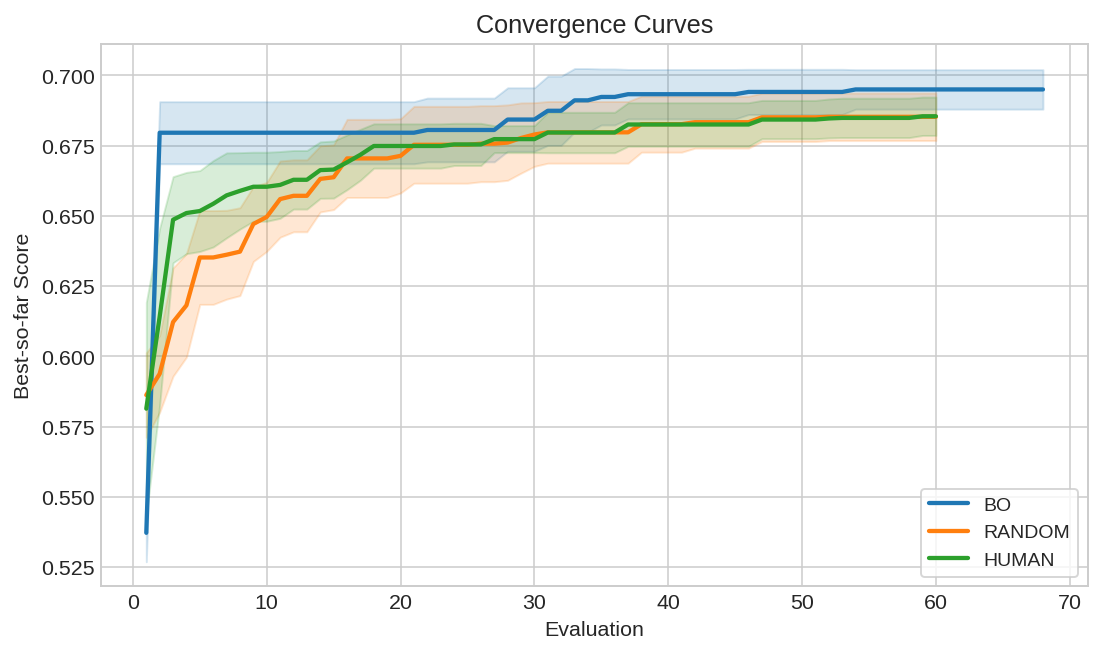

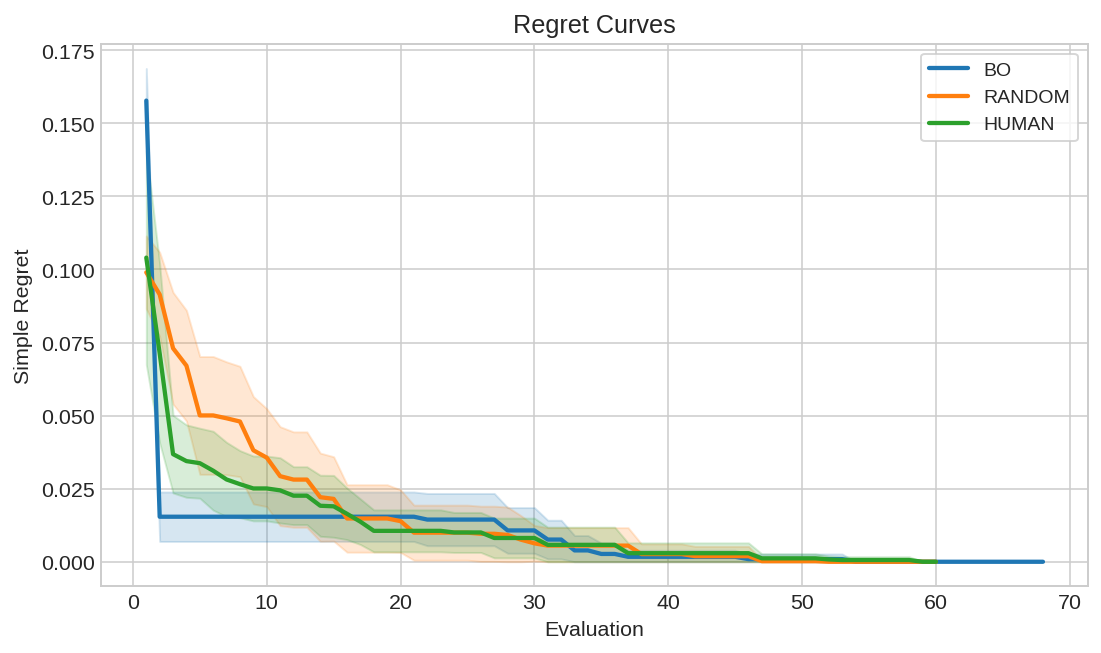

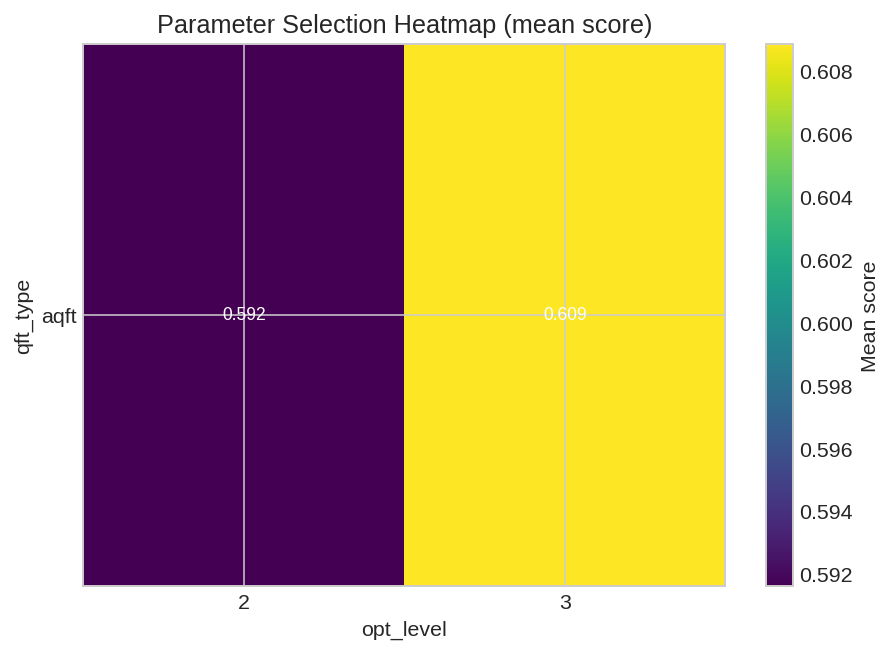

TypeError: Object of type DataFrame is not JSON serializable

In [ ]:
RUN_SCALING = False
RUN_ABLATION = False
RUN_HARDWARE = False

main_bundle = run_suite(config=CONFIG, t_count=MAIN_T_COUNT, allow_aqft=True, fixed_opt_level=None, remove_k=False, use_hardware_penalty=True, backend_ctx=BACKEND_CTX)

stats = statistical_analysis(main_bundle)
bo_analysis = interpret_bo_results(main_bundle)

plot_convergence(main_bundle)
plot_regret(main_bundle)
plot_parameter_heatmap(bo_analysis['bo_df'])

scaling_df = pd.DataFrame()
if RUN_SCALING:
    scaling_df = run_scaling_experiment(config=CONFIG, backend_ctx=BACKEND_CTX)
    plot_scaling(scaling_df)

ablation_df = pd.DataFrame()
if RUN_ABLATION:
    ablation_df, ablation_bundles = run_ablation_studies(config=CONFIG, backend_ctx=BACKEND_CTX)
    plot_ablations(ablation_df)

hardware_result = None
if RUN_HARDWARE:
    best_params_row = bo_analysis['top_configs'].sort_values('score', ascending=False).iloc[0]
    best_params = {
        'qft_type': best_params_row['param_qft_type'],
        'k': None if pd.isna(best_params_row['param_k']) else int(best_params_row['param_k']),
        'opt_level': int(best_params_row['param_opt_level']),
        't_count': int(best_params_row['param_t_count']),
        'r': int(best_params_row['param_r']),
        'layout_strategy': best_params_row['param_layout_strategy'],
        'routing_method': best_params_row['param_routing_method'],
    }
    hardware_result = validate_on_hardware(best_params, backend_ctx=BACKEND_CTX, config=CONFIG)

save_outputs(main_bundle, stats, scaling_df, ablation_df, bo_analysis, hardware_result, out_dir='results')
print_final_summary(main_bundle, stats)


